In [18]:
import sys
import time
sys.path.append('/home/student/de-ass/Task5Kafka')

from spark_streaming_config import SparkStreamingConfig
from stream_reader import StreamReader
from stream_aggregator import StreamAggregator
from stream_transformer import StreamTransformer
from stream_writer import StreamWriter
from pyspark.sql.functions import *

In [19]:
config = SparkStreamingConfig()
spark = config.create_spark_session()
spark.conf.set("spark.sql.shuffle.partitions", 5)
schema = config.get_data_schema()

reader = StreamReader(spark, schema)
aggregator = StreamAggregator(spark)
transformer = StreamTransformer(spark)
writer = StreamWriter(spark)

In [20]:
hdfs_path = "hdfs://localhost:9000/user/student/air_quality_cleaned/valid_json"
streaming = reader.read_hdfs_stream(hdfs_path, max_files_per_trigger=5)
enhanced_stream = reader.add_processing_time()

 Stream reader initialized from: hdfs://localhost:9000/user/student/air_quality_cleaned/valid_json
 Schema applied with 35 fields


In [21]:
simple_city_agg = enhanced_stream.groupBy("city", "country").agg(
    avg("AQI").alias("avg_aqi"),
    max("AQI").alias("max_aqi"),
    count("*").alias("count")
)

In [22]:
health_stream = transformer.transform_health_risk_scores(enhanced_stream)
alert_stream = transformer.transform_alert_levels(health_stream)

In [23]:
q1 = simple_city_agg.writeStream \
    .queryName("city_stats") \
    .format("memory") \
    .outputMode("complete") \
    .start()

q2 = alert_stream.writeStream \
    .queryName("alerts") \
    .format("memory") \
    .outputMode("append") \
    .start()

25/08/29 22:22:07 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-adbceb03-d445-433f-b865-dc747d0c862d. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
25/08/29 22:22:07 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
25/08/29 22:22:07 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-96b92e42-2ece-48f9-bd7f-2e2a53702e70. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
25/08/29 22:22:07 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not support

In [24]:
print("Waiting for initial data...")
time.sleep(10)

Waiting for initial data...


In [25]:
def visualize_streaming_data(iterations=5):
    for i in range(iterations):
        
        city_df = spark.sql("SELECT * FROM city_stats ORDER BY avg_aqi DESC").toPandas()
        alerts_df = spark.sql("SELECT * FROM alerts").toPandas()
        
        if not city_df.empty:
            
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            
            top_cities = city_df.nlargest(10, 'avg_aqi')
            axes[0, 0].barh(top_cities['city'], top_cities['avg_aqi'], color='coral')
            axes[0, 0].set_xlabel('Average AQI')
            axes[0, 0].set_title(f'Top 10 Cities - Iteration {i+1}')
            
            
            if not alerts_df.empty:
                alert_counts = alerts_df['health_risk_label'].value_counts()
                axes[0, 1].pie(alert_counts.values, labels=alert_counts.index, autopct='%1.1f%%')
                axes[0, 1].set_title('Health Risk Distribution')
            
            
            axes[1, 0].hist(city_df['avg_aqi'], bins=20, color='skyblue', edgecolor='black')
            axes[1, 0].set_xlabel('AQI Value')
            axes[1, 0].set_ylabel('Frequency')
            axes[1, 0].set_title('AQI Distribution')
            
            
            axes[1, 1].axis('off')
            metrics_text = f"""
            Real-Time Metrics (Update {i+1})
            --------------------------------
            Total Cities: {len(city_df)}
            Average Global AQI: {city_df['avg_aqi'].mean():.2f}
            Highest AQI: {city_df['max_aqi'].max():.2f}
            Critical Alerts: {len(alerts_df[alerts_df['AQI'] > 200]) if not alerts_df.empty else 0}
            Time: {time.strftime('%H:%M:%S')}
            """
            axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=12, family='monospace')
            
            plt.suptitle(f'Air Quality Streaming Dashboard - {time.strftime("%Y-%m-%d %H:%M:%S")}')
            plt.tight_layout()
            plt.savefig(f'dashboard_iteration_{i+1}.png')  # Save each iteration
            plt.show()
            
            
            print(f"\n{'='*60}")
            print(f"ITERATION {i+1} - Console Output")
            print('='*60)
            print("\nTop 5 Cities:")
            print(top_cities[['city', 'country', 'avg_aqi']].head())
            
        else:
            print(f"Waiting for data... Iteration {i+1}")
        
        time.sleep(10)

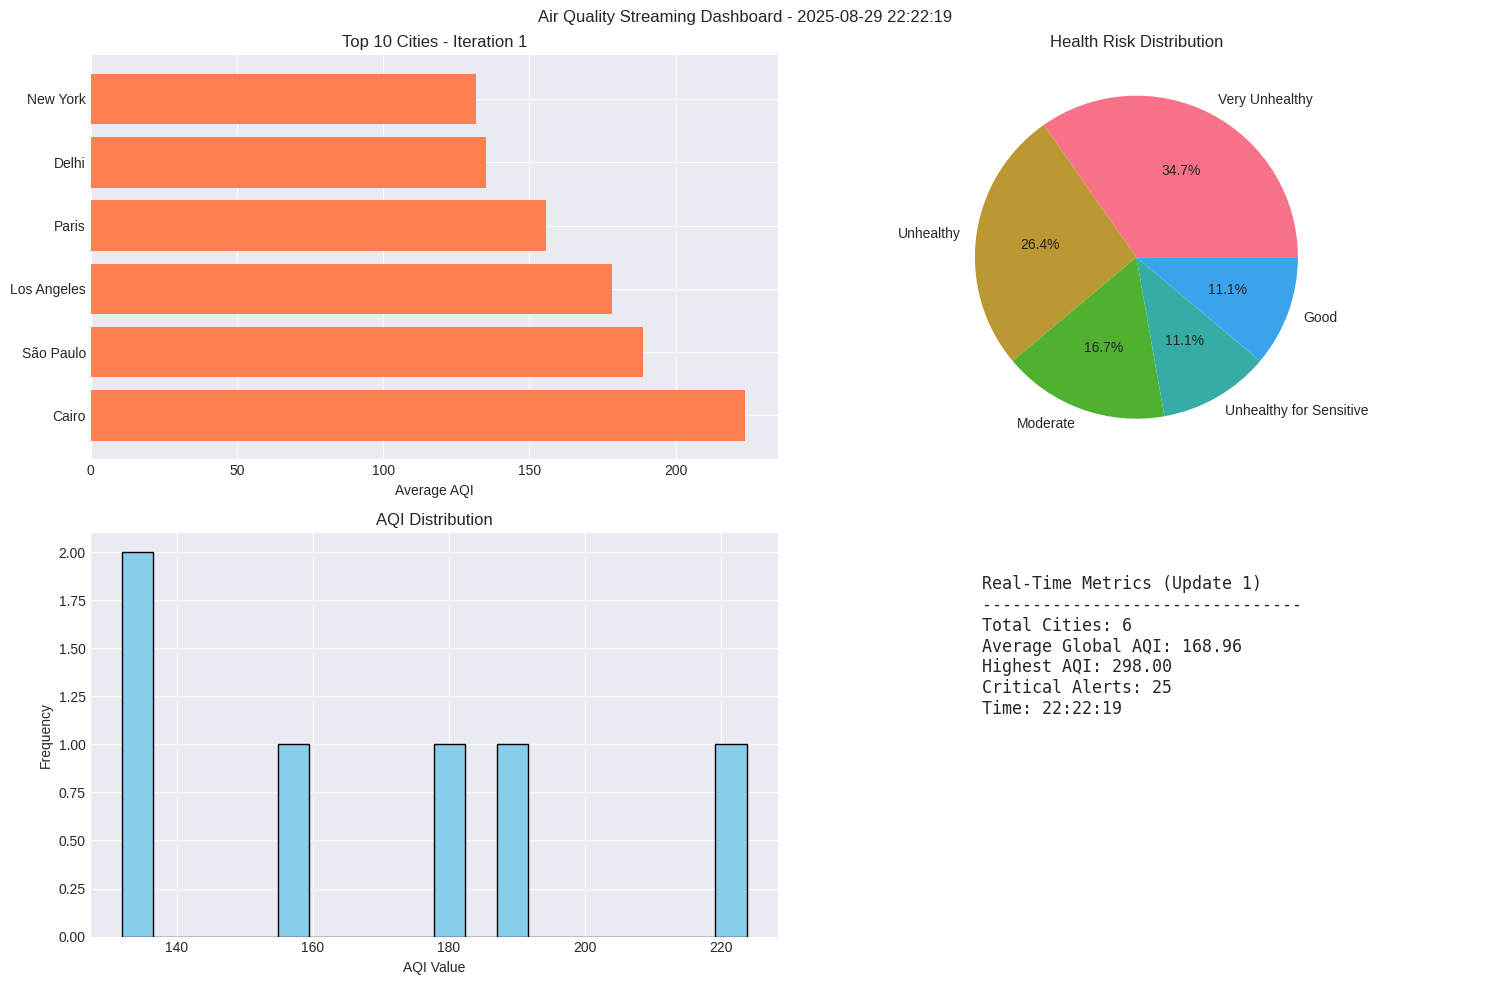


ITERATION 1 - Console Output

Top 5 Cities:
          city country     avg_aqi
0        Cairo   Egypt  223.750000
1    São Paulo  Brazil  188.833333
2  Los Angeles     USA  178.166667
3        Paris  France  155.833333
4        Delhi   India  135.250000


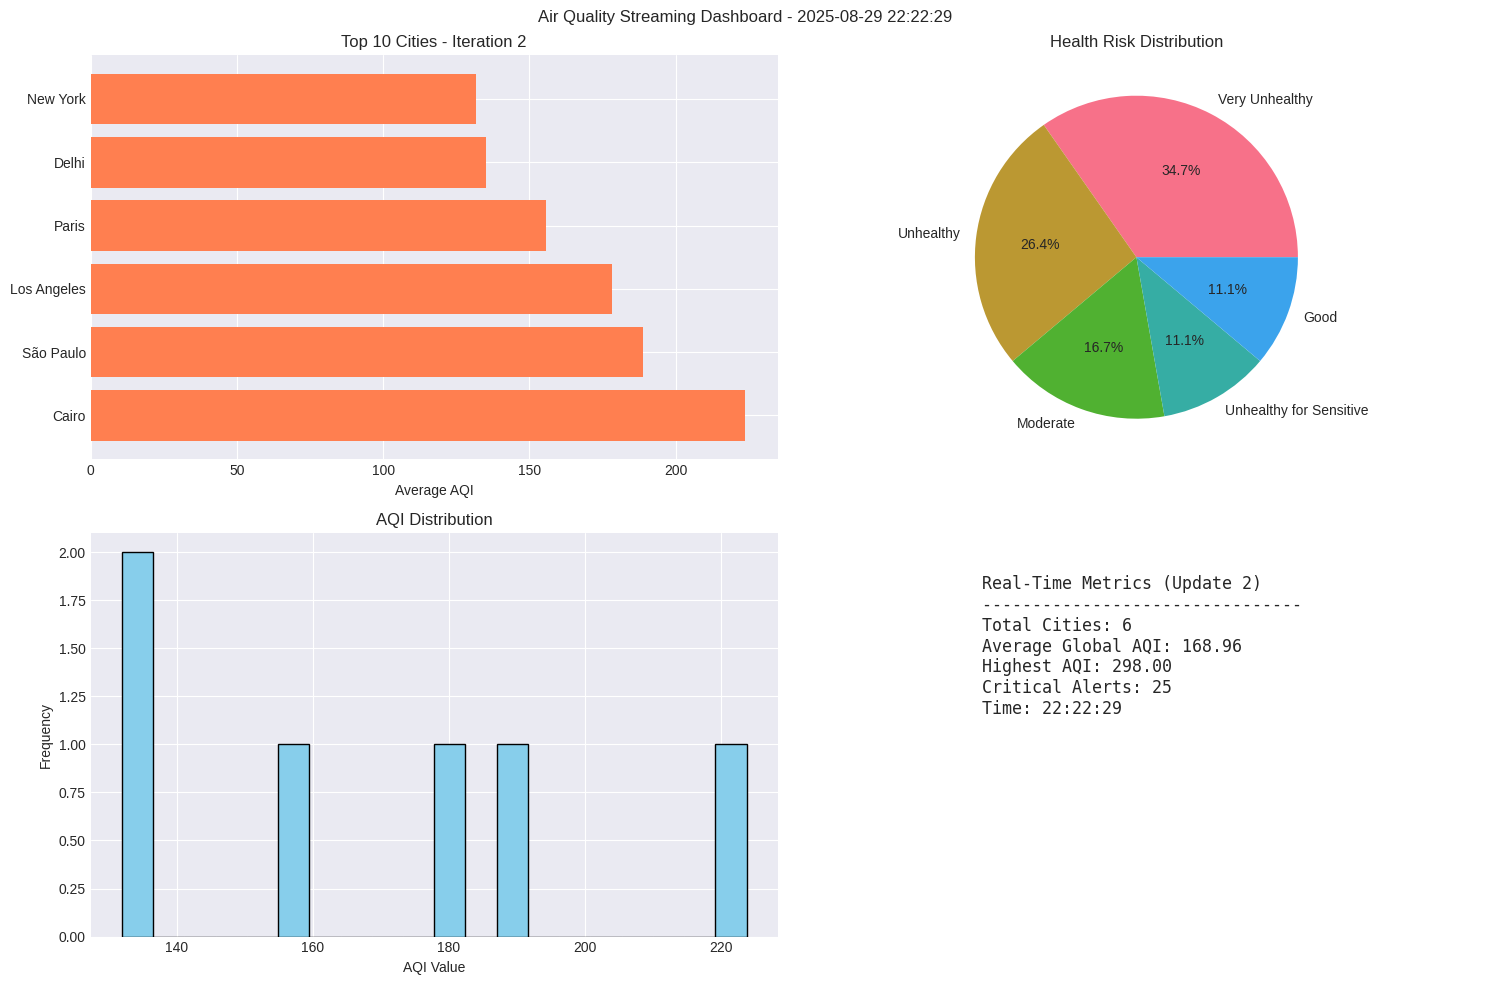


ITERATION 2 - Console Output

Top 5 Cities:
          city country     avg_aqi
0        Cairo   Egypt  223.750000
1    São Paulo  Brazil  188.833333
2  Los Angeles     USA  178.166667
3        Paris  France  155.833333
4        Delhi   India  135.250000


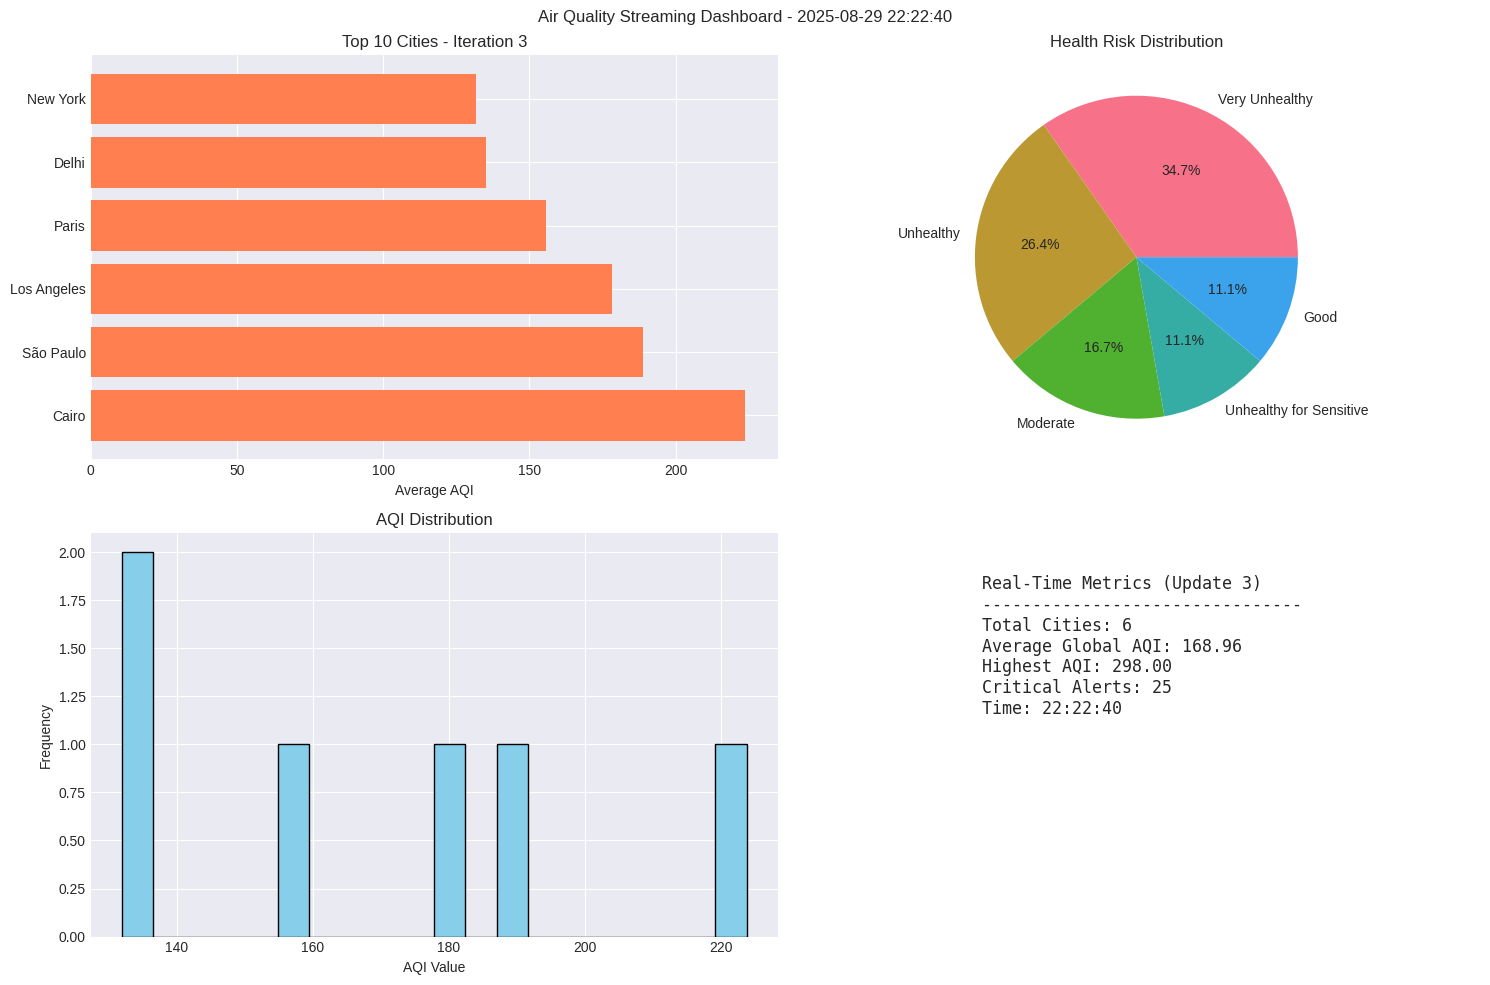


ITERATION 3 - Console Output

Top 5 Cities:
          city country     avg_aqi
0        Cairo   Egypt  223.750000
1    São Paulo  Brazil  188.833333
2  Los Angeles     USA  178.166667
3        Paris  France  155.833333
4        Delhi   India  135.250000


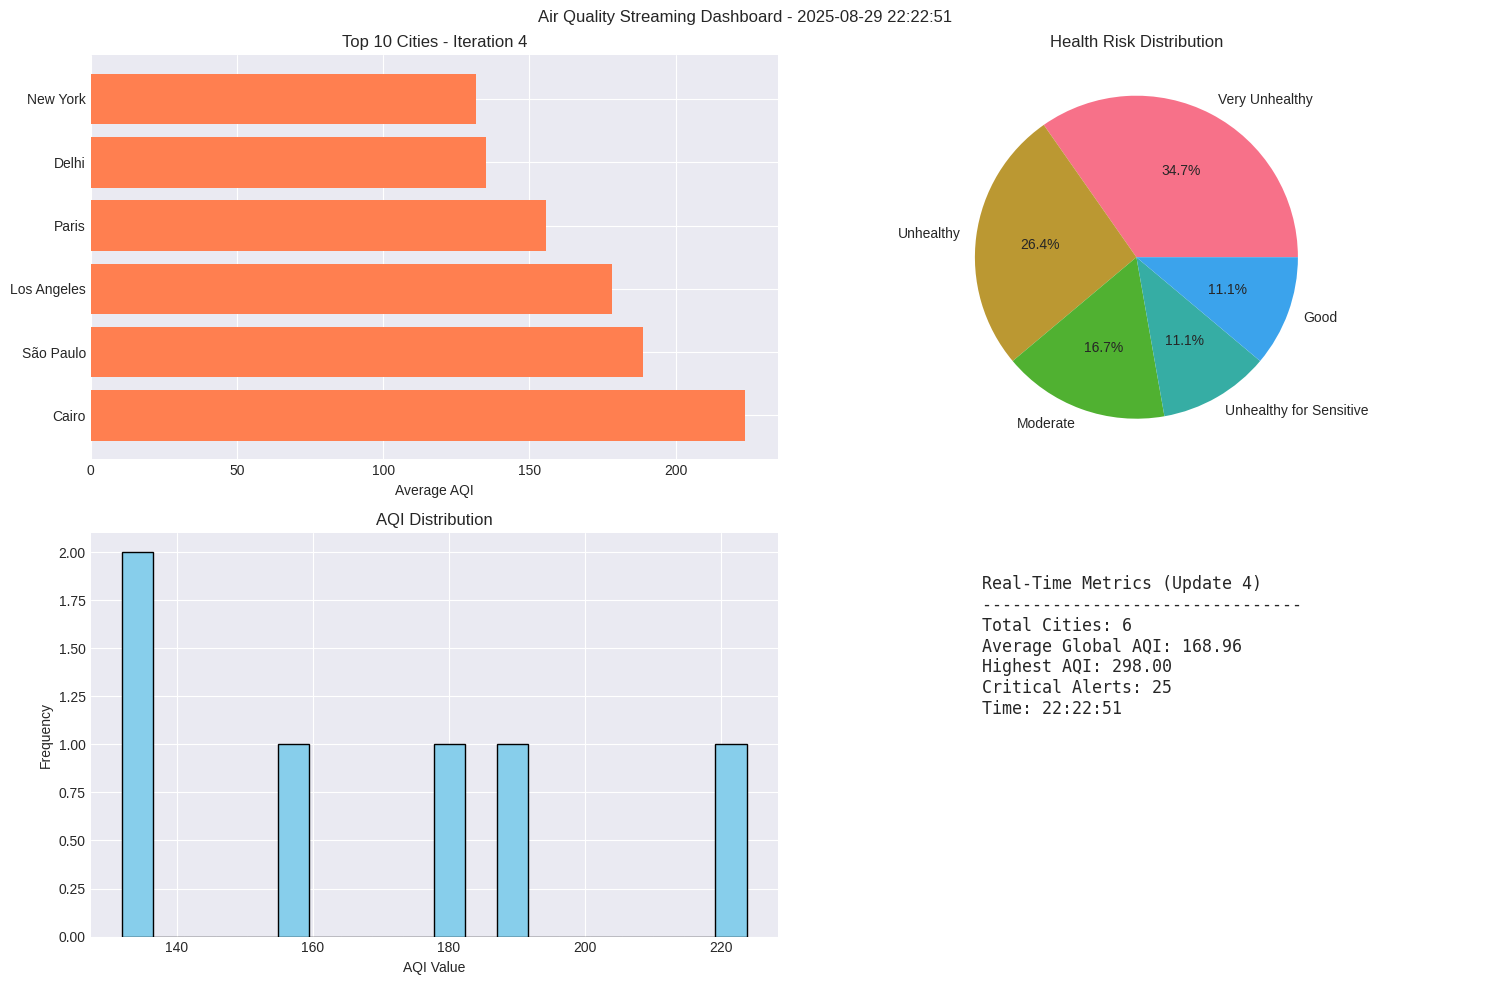


ITERATION 4 - Console Output

Top 5 Cities:
          city country     avg_aqi
0        Cairo   Egypt  223.750000
1    São Paulo  Brazil  188.833333
2  Los Angeles     USA  178.166667
3        Paris  France  155.833333
4        Delhi   India  135.250000


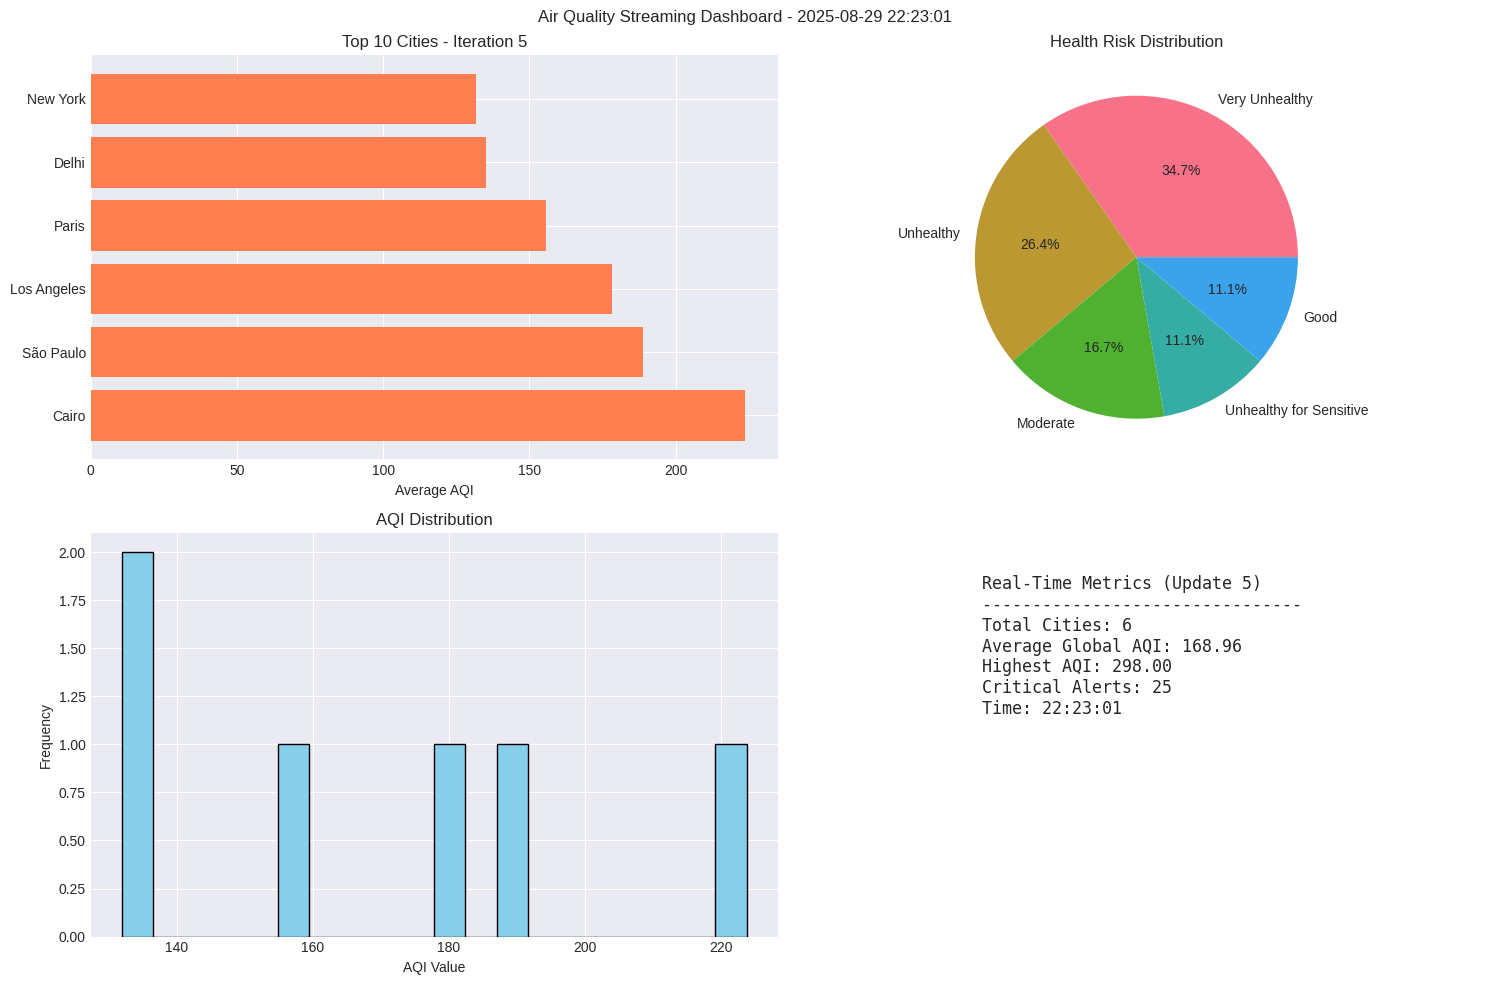


ITERATION 5 - Console Output

Top 5 Cities:
          city country     avg_aqi
0        Cairo   Egypt  223.750000
1    São Paulo  Brazil  188.833333
2  Los Angeles     USA  178.166667
3        Paris  France  155.833333
4        Delhi   India  135.250000


In [26]:
visualize_streaming_data(iterations=5)

In [27]:
for i in range(10): 
    print(f"\n{'='*60}")
    print(f"REAL-TIME UPDATE {i+1}/10 - {time.strftime('%H:%M:%S')}")
    print('='*60)
    
    city_df = spark.sql("SELECT * FROM city_stats ORDER BY avg_aqi DESC LIMIT 5")
    alerts_df = spark.sql("SELECT city, AQI, health_risk_label FROM alerts ORDER BY alert_timestamp DESC LIMIT 5")
    
    print("\nTOP CITIES BY AQI:")
    city_df.show(truncate=False)
    
    print("\nLATEST ALERTS:")
    alerts_df.show(truncate=False)
    
    city_pd = city_df.toPandas()
    if not city_pd.empty:
        print(f"\nSUMMARY:")
        print(f"- Cities monitored: {len(city_pd)}")
        print(f"- Average global AQI: {city_pd['avg_aqi'].mean():.2f}")
        print(f"- Highest AQI: {city_pd['max_aqi'].max()}")
    
    time.sleep(5)


REAL-TIME UPDATE 1/10 - 22:23:12

TOP CITIES BY AQI:
+-----------+-------+------------------+-------+-----+
|city       |country|avg_aqi           |max_aqi|count|
+-----------+-------+------------------+-------+-----+
|Cairo      |Egypt  |223.75            |298.0  |12   |
|São Paulo  |Brazil |188.83333333333334|297.0  |12   |
|Los Angeles|USA    |178.16666666666666|291.0  |12   |
|Paris      |France |155.83333333333334|297.0  |12   |
|Delhi      |India  |135.25            |278.0  |12   |
+-----------+-------+------------------+-------+-----+


LATEST ALERTS:
+-----------+-----+-----------------------+
|city       |AQI  |health_risk_label      |
+-----------+-----+-----------------------+
|Los Angeles|93.0 |Moderate               |
|New York   |171.0|Unhealthy              |
|São Paulo  |123.0|Unhealthy for Sensitive|
|New York   |169.0|Unhealthy              |
|Paris      |297.0|Very Unhealthy         |
+-----------+-----+-----------------------+


SUMMARY:
- Cities monitored: 5
- Ave

In [28]:
q1.stop()
q2.stop()
spark.stop()

25/08/29 22:24:07 WARN StateStore: Error running maintenance thread
java.lang.IllegalStateException: SparkEnv not active, cannot do maintenance on StateStores
	at org.apache.spark.sql.execution.streaming.state.StateStore$.doMaintenance(StateStore.scala:632)
	at org.apache.spark.sql.execution.streaming.state.StateStore$.$anonfun$startMaintenanceIfNeeded$1(StateStore.scala:610)
	at org.apache.spark.sql.execution.streaming.state.StateStore$MaintenanceTask$$anon$1.run(StateStore.scala:453)
	at java.util.concurrent.Executors$RunnableAdapter.call(Executors.java:511)
	at java.util.concurrent.FutureTask.runAndReset(FutureTask.java:308)
	at java.util.concurrent.ScheduledThreadPoolExecutor$ScheduledFutureTask.access$301(ScheduledThreadPoolExecutor.java:180)
	at java.util.concurrent.ScheduledThreadPoolExecutor$ScheduledFutureTask.run(ScheduledThreadPoolExecutor.java:294)
	at java.util.concurrent.ThreadPoolExecutor.runWorker(ThreadPoolExecutor.java:1149)
	at java.util.concurrent.ThreadPoolExecutor